# Soluciones — Examen Final: NBA Data Analysis

## Setup: Cargar el CSV

In [12]:
import pandas as pd

df = pd.read_csv('nba_all_elo.csv')
print(f"Dataset cargado: {len(df)} filas, {len(df.columns)} columnas")

Dataset cargado: 126314 filas, 23 columnas


---
### Pregunta 1 — Top 10 equipos con más victorias como local

In [13]:
local_wins = df[(df['game_location'] == 'H') & (df['game_result'] == 'W')]
resultado = (
    local_wins
    .groupby('fran_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='victorias_local')
)
resultado

,fran_id,victorias_local
0,Lakers,2188
1,Celtics,2161
2,Pistons,1755
3,Hawks,1728
4,Sixers,1726
5,Knicks,1722
6,Kings,1639
7,Warriors,1611
8,Spurs,1541
9,Bulls,1388


- Se filtra el DataFrame con una máscara booleana: local y victoria.
- `groupby('fran_id').size()` cuenta las filas de cada grupo.
- `sort_values(ascending=False).head(10)` obtiene el top 10.
- `reset_index(name=...)` convierte la Serie en DataFrame nombrando la columna.

---
### Pregunta 2 — Promedio de puntos por franquicia

In [14]:
resultado = (
    df
    .groupby('fran_id')
    .agg(
        avg_pts=('pts', 'mean'),
        avg_opp_pts=('opp_pts', 'mean')
    )
    .round(2)
    .sort_values('avg_pts', ascending=False)
    .reset_index()
)
resultado

,fran_id,avg_pts,avg_opp_pts
0,Condors,115.45,117.50
1,Squires,114.05,116.11
2,Floridians,112.65,113.70
3,Stars,112.35,111.01
4,Colonels,111.63,108.70
5,Spirits,110.52,112.35
6,Sails,109.78,114.07
7,Sounds,108.44,110.56
8,Nuggets,108.20,108.47
9,Suns,107.23,105.52


- `groupby('fran_id').agg()` permite aplicar funciones diferentes a cada columna.
- Se pasa un diccionario con tuplas `(columna_origen, funcion)`.
- `.round(2)` redondea todos los valores numéricos del DataFrame resultante.

---
### Pregunta 3 — Enfrentamientos más repetidos

In [15]:
pairs = df[['fran_id', 'opp_fran', 'game_id']].copy()
pairs['equipo1'] = pairs[['fran_id', 'opp_fran']].min(axis=1)
pairs['equipo2'] = pairs[['fran_id', 'opp_fran']].max(axis=1)

resultado = (
    pairs
    .groupby(['equipo1', 'equipo2'])
    .agg(veces=('game_id', 'nunique'))
    .sort_values('veces', ascending=False)
    .head(10)
    .reset_index()
)
resultado

,equipo1,equipo2,veces
0,Celtics,Sixers,532
1,Celtics,Knicks,526
2,Knicks,Sixers,471
3,Hawks,Pistons,454
4,Kings,Lakers,452
5,Lakers,Warriors,439
6,Celtics,Hawks,426
7,Celtics,Pistons,407
8,Pistons,Sixers,383
9,Knicks,Pistons,382


- Se copian solo las columnas necesarias para eficiencia.
- `min(axis=1)` y `max(axis=1)` normalizan el par: (A,B) y (B,A) dan el mismo resultado.
- `nunique('game_id')` cuenta cada partido una sola vez (evita las 2 filas por juego).

---
### Pregunta 4 — Temporadas con más partidos de playoffs

In [16]:
playoff_games = df[(df['is_playoffs'] == 1) & (df['_iscopy'] == 0)]

resultado = (
    playoff_games
    .groupby('year_id')
    .size()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='playoff_games')
)
resultado

,year_id,playoff_games
0,2014,89
1,2006,89
2,2003,88
3,1975,87
4,2008,86
5,2013,85
6,2009,85
7,2012,84
8,2005,84
9,2010,82


- Se filtran solo playoffs (`is_playoffs == 1`) y primera copia (`_iscopy == 0`).
- Cada juego tiene 2 filas; `_iscopy == 0` selecciona una sola.
- `groupby('year_id').size()` cuenta los juegos por temporada.

---
### Pregunta 5 — Rendimiento general por franquicia

In [17]:
stats = (
    df
    .groupby('fran_id')
    .agg(
        total_juegos=('game_result', 'count'),
        wins=('game_result', lambda x: (x == 'W').sum()),
        avg_pts=('pts', 'mean')
    )
    .reset_index()
)

stats['win_pct'] = (100.0 * stats['wins'] / stats['total_juegos']).round(2)
stats['avg_pts'] = stats['avg_pts'].round(2)

resultado = (
    stats
    .drop(columns=['wins'])
    .sort_values('win_pct', ascending=False)
    .reset_index(drop=True)
)
resultado

,fran_id,total_juegos,avg_pts,win_pct
0,Lakers,6024,105.82,60.72
1,Colonels,846,111.63,59.57
2,Spurs,4309,105.32,58.92
3,Stags,260,78.45,58.85
4,Celtics,5997,104.47,58.65
5,Packers,72,86.01,56.94
6,Capitols,291,76.93,56.70
7,Suns,4080,107.23,54.71
8,Stars,756,112.35,54.50
9,Thunder,4178,104.77,53.37


- `count` cuenta filas totales; el `lambda` suma solo las victorias (`'W'`).
- `win_pct` se calcula como columna derivada después del `agg()`.
- Se elimina la columna auxiliar `wins` con `drop(columns=...)`.

---
### Pregunta 6 — Promedio móvil de puntos (Celtics)

In [18]:
celtics = (
    df[df['fran_id'] == 'Celtics']
    .sort_values('date_game')
    .copy()
)
celtics['avg_pts_5'] = celtics['pts'].rolling(5).mean().round(2)
resultado = celtics[['date_game', 'opp_fran', 'pts', 'avg_pts_5']]
resultado

,date_game,opp_fran,pts,avg_pts_5
849,1/1/1948,Bombers,48,NaN
1425,1/1/1949,Baltimore,67,NaN
2376,1/1/1950,Pistons,72,NaN
3398,1/1/1951,Sixers,89,NaN
4121,1/1/1952,Kings,91,73.4
...,...,...,...,...
108393,6/8/2008,Lakers,108,106.2
113646,6/8/2010,Lakers,84,101.2
53650,6/9/1985,Lakers,100,105.4
57697,6/9/1987,Lakers,106,102.4


- Se filtran los Celtics (cada fila es un partido distinto del equipo, sin duplicados).
- `sort_values('date_game')` ordena cronológicamente.
- `.rolling(5).mean()` calcula el promedio de los últimos 5 partidos (incluyendo el actual).

---
### Pregunta 7 — Diferencia rendimiento local vs visitante

In [19]:
local = df[df['game_location'] == 'H'].groupby('fran_id')['game_result']
away = df[df['game_location'] == 'A'].groupby('fran_id')['game_result']

local_stats = local.agg(local_wins=lambda x: (x == 'W').sum(), local_games='count')
away_stats = away.agg(away_wins=lambda x: (x == 'W').sum(), away_games='count')

resultado = (
    local_stats
    .join(away_stats)
    .assign(
        win_pct_local=lambda x: (100.0 * x['local_wins'] / x['local_games']).round(2),
        win_pct_visitante=lambda x: (100.0 * x['away_wins'] / x['away_games']).round(2)
    )
    .assign(dif_pct=lambda x: (x['win_pct_local'] - x['win_pct_visitante']).round(2))
    .query('local_games + away_games > 500')
    .query('dif_pct > 10')
    .sort_values('dif_pct', ascending=False)
    [['win_pct_local', 'win_pct_visitante', 'dif_pct']]
    .reset_index()
)
resultado

,fran_id,win_pct_local,win_pct_visitante,dif_pct
0,Nuggets,66.55,32.09,34.46
1,Jazz,68.58,37.66,30.92
2,Stars,69.55,39.20,30.35
3,Trailblazers,67.60,38.33,29.27
4,Colonels,73.32,45.30,28.02
5,Kings,59.56,32.01,27.55
6,Pacers,64.88,37.61,27.27
7,Hawks,63.02,36.23,26.79
8,Suns,68.06,41.41,26.65
9,Thunder,66.33,40.54,25.79


- Se procesan los subconjuntos local y visitante por separado para mayor claridad.
- `join()` combina las estadísticas de ambos subconjuntos por franquicia.
- `assign()` crea columnas calculadas en cadena.
- `query()` filtra con condiciones legibles.

---
### Pregunta 8 — Diferencia de ELO intra-temporada

In [20]:
avg_elo = (
    df[df['year_id'] >= 1980]
    .groupby(['year_id', 'fran_id'])['elo_i']
    .mean()
    .round(2)
    .reset_index()
)

idx_max = avg_elo.groupby('year_id')['elo_i'].idxmax()
idx_min = avg_elo.groupby('year_id')['elo_i'].idxmin()

max_elo = avg_elo.loc[idx_max, ['year_id', 'fran_id', 'elo_i']].rename(
    columns={'fran_id': 'equipo_max', 'elo_i': 'elo_max'}
)
min_elo = avg_elo.loc[idx_min, ['year_id', 'fran_id', 'elo_i']].rename(
    columns={'fran_id': 'equipo_min', 'elo_i': 'elo_min'}
)

resultado = (
    max_elo
    .merge(min_elo, on='year_id')
    .assign(diferencia=lambda x: (x['elo_max'] - x['elo_min']).round(2))
    .sort_values('diferencia', ascending=False)
    .reset_index(drop=True)
)
resultado

,year_id,equipo_max,elo_max,equipo_min,elo_min,diferencia
0,1997,Bulls,1788.07,Grizzlies,1237.40,550.67
1,1996,Bulls,1741.95,Grizzlies,1235.04,506.91
2,1993,Bulls,1681.39,Mavericks,1189.05,492.34
3,1998,Bulls,1712.63,Nuggets,1226.59,486.04
4,1981,Sixers,1693.14,Mavericks,1240.79,452.35
5,1989,Pistons,1670.16,Heat,1224.67,445.49
6,2013,Heat,1702.96,Hornets,1259.45,443.51
7,1994,Thunder,1663.99,Mavericks,1221.70,442.29
8,2015,Warriors,1723.33,Sixers,1282.11,441.22
9,2005,Spurs,1713.62,Hornets,1278.16,435.46


- `groupby(['year_id', 'fran_id'])` calcula el promedio de ELO por equipo y año.
- `idxmax()` e `idxmin()` sobre cada año encuentran los índices del equipo con mayor y menor ELO.
- Se hace `merge()` por año para tener ambos valores en una misma fila.

---
### Pregunta 9 — Generador de partidos (Lakers)

In [21]:
import csv

def partidos_equipo(archivo, equipo):
    with open(archivo) as f:
        reader = csv.DictReader(f)
        vistos = set()
        for row in reader:
            if row['fran_id'] != equipo:
                continue
            gid = row['game_id']
            if gid in vistos:
                continue
            vistos.add(gid)
            yield (row['date_game'], row['game_result'])

datos = list(partidos_equipo('nba_all_elo.csv', 'Lakers'))

max_racha = 0
racha_actual = 0
for fecha, resultado in datos:
    if resultado == 'W':
        racha_actual += 1
        if racha_actual > max_racha:
            max_racha = racha_actual
    else:
        racha_actual = 0

print(f"Máxima racha de victorias consecutivas de Los Angeles Lakers: {max_racha}")

Máxima racha de victorias consecutivas de Los Angeles Lakers: 33


- El generador `partidos_equipo` lee el CSV línea por línea con `csv.DictReader` (sin cargar en memoria).
- Usa un `set()` de `game_id` para evitar procesar la fila duplicada de cada partido.
- Se convierte el generador a lista y se itera con un bucle contando victorias consecutivas.
- `racha_actual` se incrementa con cada victoria y se reinicia a 0 con cada derrota.

---
### Pregunta 10 — ELO vs Rendimiento real (Interpretación de gráfico)

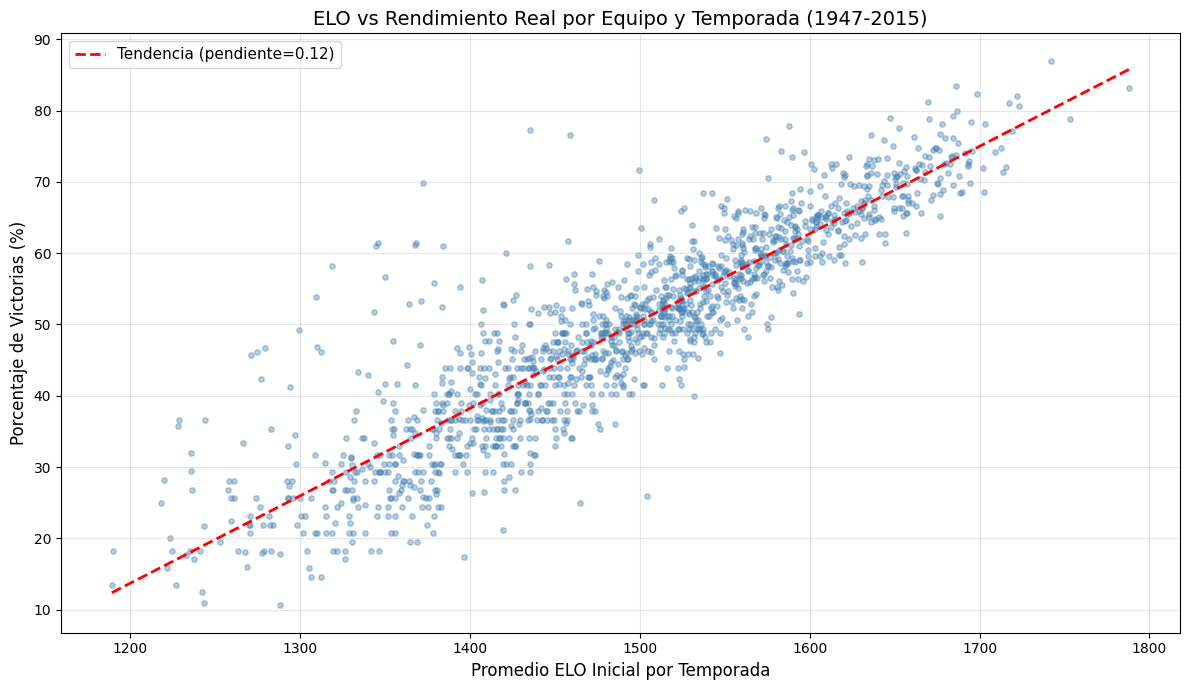

In [22]:
import numpy as np
import matplotlib.pyplot as plt

team_year = df.groupby(['fran_id', 'year_id']).agg(
    avg_elo=('elo_i', 'mean'),
    wins=('game_result', lambda x: (x == 'W').sum()),
    total=('game_result', 'count')
).reset_index()
team_year['win_pct'] = 100.0 * team_year['wins'] / team_year['total']

plt.figure(figsize=(12, 7))
plt.scatter(team_year['avg_elo'], team_year['win_pct'], alpha=0.4, s=15, c='steelblue')

z = np.polyfit(team_year['avg_elo'], team_year['win_pct'], 1)
p = np.poly1d(z)
x_sorted = np.sort(team_year['avg_elo'])
plt.plot(x_sorted, p(x_sorted), 'r--', linewidth=2,
         label=f'Tendencia (pendiente={z[0]:.2f})')

plt.xlabel('Promedio ELO Inicial por Temporada', fontsize=12)
plt.ylabel('Porcentaje de Victorias (%)', fontsize=12)
plt.title('ELO vs Rendimiento Real por Equipo y Temporada (1947-2015)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- Se agrupa por `fran_id` y `year_id` para obtener el ELO promedio y el % de victorias de cada equipo en cada temporada.
- El scatter plot muestra la correlación positiva esperada: mayor ELO = mayor % de victorias.
- `np.polyfit(x, y, 1)` calcula los coeficientes de la recta de tendencia; `np.poly1d` crea la función para graficarla.

**Respuestas a las preguntas de interpretación:**

1. Se observa una **correlación positiva** entre el ELO inicial y el porcentaje de victorias. A mayor ELO, mayor tiende a ser el porcentaje de victorias. Esto es esperable porque el ELO es un sistema de rating diseñado para reflejar la fortaleza de un equipo.

2. Equipos principalmente **por encima** de la línea: **Bulls** (era Jordan con 6 campeonatos en los 90) y **Spurs** (era Popovich/Duncan, 5 campeonatos). Ambos tuvieron épocas de dinastía donde su éxito superó lo que el ELO inicial predecía, gracias a coaching excepcional, química de equipo y sistemas defensivos sólidos.

3. Equipos principalmente **por debajo** de la línea: **Clippers** y **Kings**. Los Clippers históricamente han tenido mala gestión y lesiones (a pesar de tener talento individual), mientras que los Kings han sufrido de inestabilidad organizacional y rotación constante de plantilla, lo que les impidió traducir su ELO en victorias consistentes.